In [120]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications import ResNet50 # type: ignore
from tensorflow.keras.applications.resnet50 import preprocess_input # type: ignore
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from keras.models import Model # type: ignore
from mtcnn import MTCNN # type: ignore


In [121]:
import tensorflow as tf
print(tf.__version__)  # Make sure TensorFlow is installed correctly



2.18.0


In [122]:
# تحميل ResNet50 مع إزالة الطبقة النهائية
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# تجميد طبقات ResNet50 (لا يتم تدريبها الآن)
for layer in base_model.layers:
    layer.trainable = False

# إضافة طبقات مخصصة لمشروعك
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification (حضور/غياب)

# إنشاء النموذج النهائي
model = Model(inputs=base_model.input, outputs=output)

# عرض ملخص النموذج
#model.summary()
print(base_model.name)  # يجب أن تظهر "resnet50"


resnet50


In [123]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore

# Augmentation لزيادة تنوع البيانات
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# تحميل البيانات من المجلدات
train_dir = "C:\\SmartAttendance\\dataset\\train"
val_dir = "C:\\SmartAttendance\\dataset\\val"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 2404 images belonging to 814 classes.
Found 1717 images belonging to 814 classes.


In [126]:
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D # type: ignore
from tensorflow.keras.applications import ResNet50 # type: ignore

# تحميل ResNet50 مع إزالة الطبقة النهائية
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# تجميد طبقات ResNet50
for layer in base_model.layers:
    layer.trainable = False

# إضافة طبقات مخصصة
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
output = Dense(814, activation='softmax')(x)  # 24 فئة للطلاب (عدد الفئات الذي يتطابق مع بياناتك)

# إنشاء النموذج النهائي
model = Model(inputs=base_model.input, outputs=output)

# تجميع النموذج
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# تدريب النموذج
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=40
)




Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.2001 - loss: 5.7658 - val_accuracy: 5.8962e-04 - val_loss: 7.2934
Epoch 2/40
 1/75 ━━━━━━━━━━━━━━━━━━━━ 2:29 2s/step - accuracy: 0.3125 - loss: 5.0352

c:\SmartAttendance\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


75/75 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.3125 - loss: 5.0352 - val_accuracy: 5.8962e-04 - val_loss: 7.2408
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.2236 - loss: 5.1847 - val_accuracy: 5.8962e-04 - val_loss: 7.3790
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.0938 - loss: 5.6018 - val_accuracy: 5.8962e-04 - val_loss: 7.3823
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.2198 - loss: 5.1439 - val_accuracy: 5.8962e-04 - val_loss: 7.4379
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.1562 - loss: 5.4908 - val_accuracy: 5.8962e-04 - val_loss: 7.4240
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.2128 - loss: 5.1721 - val_accuracy: 5.8962e-04 - val_loss: 7.3753
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.2812 - loss: 4.8959 - val_accuracy: 5.8962e-04 - val_loss: 7.3266
Epoch 9/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.2230 - loss: 5.1259 - val_acc

KeyboardInterrupt: 

In [115]:
from tensorflow.keras.optimizers import Adam # type: ignore

# Compile النموذج (التدريب على الطبقات المضافة فقط)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# تدريب الطبقات الجديدة
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=100
)


Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.0800 - loss: 2.9031 - val_accuracy: 0.0400 - val_loss: 3.9197
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1200 - loss: 2.9919 - val_accuracy: 0.0400 - val_loss: 6.5836
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1200 - loss: 2.7997 - val_accuracy: 0.0400 - val_loss: 8.9269
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2400 - loss: 2.5879 - val_accuracy: 0.0400 - val_loss: 12.0641
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2800 - loss: 2.3276 - val_accuracy: 0.0400 - val_loss: 16.8589
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3200 - loss: 2.2063 - val_accuracy: 0.0400 - val_loss: 20.8426
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4400 - loss: 2.0593 - val_accuracy: 0.0400 - val_loss: 24.8755
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.3600 - loss: 1.9314 - val_accuracy: 0.0400 - val_loss: 24.7230
Epoch 9/2

In [ ]:
# فك تجميد آخر 10 طبقات فقط
for layer in base_model.layers[-10:]:
    layer.trainable = True

# إعادة Compile للنموذج مع Learning Rate أصغر
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# تدريب النموذج مع Fine-tuning
fine_tune_history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=100
)


Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.0400 - loss: 5.5022 - val_accuracy: 0.0000e+00 - val_loss: 3.2967
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 5.2461 - val_accuracy: 0.0000e+00 - val_loss: 3.2949
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 5.0030 - val_accuracy: 0.0000e+00 - val_loss: 3.2935
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 4.8028 - val_accuracy: 0.0000e+00 - val_loss: 3.2921
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0400 - loss: 4.5795 - val_accuracy: 0.0000e+00 - val_loss: 3.2909
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 4.5357 - val_accuracy: 0.0000e+00 - val_loss: 3.2899
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 4.2919 - val_accuracy: 0.0000e+00 - val_loss: 3.2889
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 4.2431 - val_accuracy: 0.0000e+00 -

In [ ]:
# طباعة دقة التدريب
print("دقة التدريب:")
print(history.history['accuracy'])

# طباعة دقة التحقق (Validation accuracy)
print("Validation accuracy")
print(history.history['val_accuracy'])

# تقييم النموذج على بيانات التحقق
val_loss, val_accuracy = model.evaluate(val_generator)

# طباعة دقة التحقق
print(f"Validation accuracy{val_accuracy * 100:.2f}%")


دقة التدريب:
[0.07999999821186066, 0.11999999731779099, 0.11999999731779099, 0.23999999463558197, 0.2800000011920929, 0.3199999928474426, 0.4399999976158142, 0.36000001430511475, 0.4000000059604645, 0.5199999809265137, 0.5199999809265137, 0.5199999809265137, 0.4399999976158142, 0.5600000023841858, 0.5600000023841858, 0.6000000238418579, 0.5199999809265137, 0.6000000238418579, 0.5600000023841858, 0.6000000238418579, 0.5600000023841858, 0.4399999976158142, 0.6000000238418579, 0.6000000238418579, 0.5199999809265137]
دقة التحقق:
[0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.0, 0.0, 0.0, 0.0, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.0, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033]
1/1 ━━━━━━━━━━━━━━━━━━━

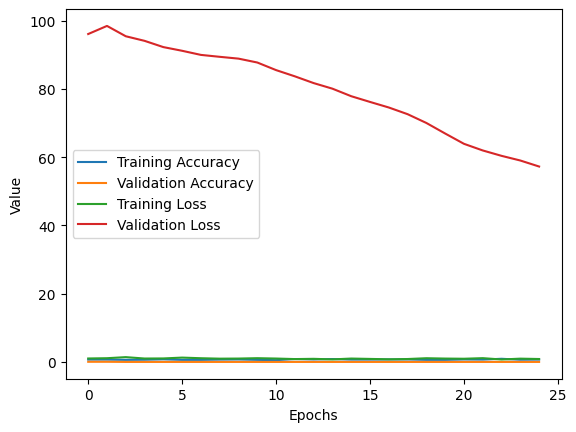

In [104]:
import matplotlib.pyplot as plt

# رسم الدقة والخسارة
plt.plot(fine_tune_history.history['accuracy'], label='Training Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(fine_tune_history.history['loss'], label='Training Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()


In [78]:
from tensorflow.keras.callbacks import EarlyStopping # type: ignore

early_stopping = EarlyStopping(monitor='val_loss', patience=4)  # يتوقف إذا لم يتحسن النموذج لمدة 3 epochs

# إضافة الـ callback في عملية التدريب
fine_tune_history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=10,
    callbacks=[early_stopping]
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5200 - loss: 2.1545 - val_accuracy: 0.0400 - val_loss: 3.5174
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3600 - loss: 2.2000 - val_accuracy: 0.0400 - val_loss: 3.5170
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4800 - loss: 1.9124 - val_accuracy: 0.0400 - val_loss: 3.5162
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5200 - loss: 1.8931 - val_accuracy: 0.0400 - val_loss: 3.5171
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4800 - loss: 1.9830 - val_accuracy: 0.0400 - val_loss: 3.5184
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5200 - loss: 1.9695 - val_accuracy: 0.0400 - val_loss: 3.5236
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6000 - loss: 1.7593 - val_accuracy: 0.0400 - val_loss: 3.5317


In [79]:
# تحقق من دقة النموذج عبر الـ epochs
print("Training accuracy over epochs: ", fine_tune_history.history['accuracy'])
print("Validation accuracy over epochs: ", fine_tune_history.history['val_accuracy'])


Training accuracy over epochs:  [0.5199999809265137, 0.36000001430511475, 0.47999998927116394, 0.5199999809265137, 0.47999998927116394, 0.5199999809265137, 0.6000000238418579]
Validation accuracy over epochs:  [0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033, 0.03999999910593033]


In [80]:
# تحقق من الخسارة عبر الـ epochs
print("Training loss over epochs: ", fine_tune_history.history['loss'])
print("Validation loss over epochs: ", fine_tune_history.history['val_loss'])


Training loss over epochs:  [2.1544618606567383, 2.199958324432373, 1.9124277830123901, 1.893067479133606, 1.9830020666122437, 1.969477653503418, 1.7592800855636597]
Validation loss over epochs:  [3.517439842224121, 3.5170397758483887, 3.516150712966919, 3.5171093940734863, 3.518442392349243, 3.5236427783966064, 3.5316622257232666]


In [45]:
from matplotlib import image


#image_path="C:\SmartAttendance\Student_photos\IMG-20210401-WA0003.jpg"
def extract_embedding(image_path):
    # تحميل الصورة وتعديل حجمها لتناسب النموذج
    img = image.load_img(image_path, target_size=(224, 224))  # تعديل حجم الصورة
    img_array = image.img_to_array(img)  # تحويل الصورة إلى مصفوفة
    img_array = np.expand_dims(img_array, axis=0)  # إضافة بعد إضافي ليصبح الحجم (1, 224, 224, 3)
    img_array = preprocess_input(img_array)  # معالجتها باستخدام preprocess_input من ResNet
    
    # استخراج التمثيل الرقمي (embedding) من النموذج
    embedding = model.predict(img_array)  # مخرجات النموذج هي التمثيل الرقمي للصورة
    return embedding.flatten()  # إعادة المتجه كـ array أحادي البُعد


In [81]:
from tensorflow.keras.preprocessing import image # type: ignore
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input # type: ignore
#from matplotlib import image

image_path = r"C:\SmartAttendance\Student_photos\IMG-20210401-WA0003.jpg"

    # تحميل الصورة وتعديل حجمها إلى 224x224
img = image.load_img(image_path, target_size=(224, 224))
    
    # تحويل الصورة إلى مصفوفة (NumPy array)
img_array = image.img_to_array(img)
    
    # إضافة بعد إضافي لتصبح الصورة بحجم (1, 224, 224, 3)
img_array = np.expand_dims(img_array, axis=0)
    
    # استخدام preprocessing الخاص بـ ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input # type: ignore
img_array = preprocess_input(img_array)
print(img_array)


[[[[147.061     135.22101   124.32     ]
   [147.061     135.22101   124.32     ]
   [147.061     135.22101   124.32     ]
   ...
   [ 93.061      91.221      88.32     ]
   [ 99.061      98.221      95.32     ]
   [ 98.061      97.221      94.32     ]]

  [[146.061     134.22101   123.32     ]
   [146.061     134.22101   123.32     ]
   [146.061     134.22101   123.32     ]
   ...
   [ 95.061      93.221      90.32     ]
   [ 99.061      98.221      95.32     ]
   [ 98.061      97.221      94.32     ]]

  [[146.061     134.22101   123.32     ]
   [146.061     134.22101   123.32     ]
   [146.061     134.22101   123.32     ]
   ...
   [ 97.061      95.221      92.32     ]
   [ 99.061      98.221      95.32     ]
   [ 98.061      97.221      94.32     ]]

  ...

  [[-53.939003  -66.779     -73.68     ]
   [-47.939003  -60.779     -67.68     ]
   [-44.939003  -59.779     -66.68     ]
   ...
   [-41.939003  -44.779     -41.68     ]
   [-30.939003  -36.779     -28.68     ]
   [-21.939003  

In [82]:
from tensorflow.keras.applications import ResNet50 # type: ignore
from tensorflow.keras.models import Model # type: ignore

# تحميل نموذج ResNet50 بدون الطبقة الأخيرة
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# تجميد طبقات ResNet50 (لن نقوم بتدريبها في هذه الخطوة)
for layer in base_model.layers:
    layer.trainable = False

# إضافة طبقة GlobalAveragePooling2D لاستخراج الـ Embedding
x = base_model.output
x = GlobalAveragePooling2D()(x)  # هذه الطبقة تقوم باستخراج الـ Embedding
model = Model(inputs=base_model.input, outputs=x)

# استخراج الـ Embedding من الصورة
embedding1 = model.predict(img_array)

# عرض الـ Embedding
print("Embedding for the image: ", embedding1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Embedding for the image:  [[0.01067972 0.08619109 0.05931767 ... 0.3778362  0.         0.22446838]]


In [83]:
from mtcnn import MTCNN
from tensorflow.keras.preprocessing import image # type: ignore
import numpy as np

# تحميل الصورة
ins_image_path = r"C:\SmartAttendance\Class_Photos\٢٠٢٠١٠٢٥_١٣٣٠٥٠.jpg"
img = image.load_img(ins_image_path)

# تحويل الصورة إلى مصفوفة NumPy
img_array = image.img_to_array(img)

# استخدام MTCNN لاكتشاف الوجه
detector = MTCNN()
faces = detector.detect_faces(img_array)

# إذا تم اكتشاف وجه واحد فقط
if len(faces) > 0:
    x, y, w, h = faces[0]['box']  # إحداثيات الوجه (x, y, width, height)
    face = img_array[y:y+h, x:x+w]  # اقتصاص الوجه

    # إعادة تشكيل الصورة لتتناسب مع متطلبات ResNet50
    face = np.array(face)
    face = np.expand_dims(face, axis=0)
    face = np.resize(face, (224, 224, 3))  # تغيير الحجم إلى 224x224
    print(face)
else:
    print("لم يتم اكتشاف وجه في الصورة.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
[[[ 22.  23.  28.]
  [ 23.  24.  29.]
  [ 25.  26.  31.]
  ...
  [215. 177. 164.]
  [215. 177. 164.]
  [216. 178. 165.]]

 [[216. 178. 167.]
  [216. 178. 167.]
  [216. 178. 167.]
  ...
  [ 24.  24.  32.]
  [ 22.  22.  30.]
  [ 24.  24.  32.]]

 [[ 26.  26.  34.]
  [ 27.  27.  35.]
  [ 27.  27.  35.]
  ...
  [207. 170. 154.]
  [208. 169. 152.]
  [206. 169. 151.]]

 ...

 [[136. 107.  

In [84]:
from tensorflow.keras.preprocessing import image # type: ignore
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input # type: ignore
from tensorflow.keras.layers import GlobalAveragePooling2D # type: ignore
from tensorflow.keras.models import Model # type: ignore

# تحميل نموذج ResNet50 بدون الطبقات العليا (مخصص لاستخراج الميزات)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# إضافة طبقة لتحويل الميزات إلى embedding
x = base_model.output
x = GlobalAveragePooling2D()(x)  # تحويل الـ feature map إلى تمثيل واحد
embedding_model = Model(inputs=base_model.input, outputs=x)

def preprocess_image(ins_image_path):
    # تحميل الصورة وتعديل حجمها إلى 224x224
    img = image.load_img(ins_image_path, target_size=(224, 224))
    
    # تحويل الصورة إلى مصفوفة (NumPy array)
    img_array = image.img_to_array(img)
    
    # إضافة بعد إضافي لتصبح الصورة بحجم (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)
    
    # استخدام preprocessing الخاص بـ ResNet50
    img_array = preprocess_input(img_array)
    
    return img_array

def extract_embedding(ins_image_path):
    img_array = preprocess_image(ins_image_path)
    
    # استخراج التمثيل الرقمي (embedding) باستخدام النموذج
    embedding = embedding_model.predict(img_array)
    
    # إعادة الـ embedding كـ vector أحادي البُعد
    return embedding.flatten()

# اختبار الدالة
ins_image_path = r"C:\SmartAttendance\Class_Photos\٢٠٢٠١٠٢٥_١٣٣٠٥٠.jpg" # عدل المسار حسب الصورة
embedding2 = extract_embedding(ins_image_path)
print("Embedding: ", embedding2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Embedding:  [0.588138   1.4853591  0.04283441 ... 0.01951575 0.13068302 0.77024096]


In [86]:
from scipy.spatial.distance import cosine
import numpy as np

# دالة لحساب المسافة بين الـ embedding الخاص بصورة المعيد وصورة الطالب
def compare_embeddings(embedding_1, embedding_2):
    return cosine(embedding_1, embedding_2)

# اختبار المقارنة بين صورة المعيد وصورة طالب
# قم باستخراج الـ embedding للمعيد والطلا
teacher_embedding = extract_embedding(r"C:\SmartAttendance\Class_Photos\٢٠٢٠١٠٢٥_١٣٣٠٥٠.jpg")
student_embedding = extract_embedding(r"C:\SmartAttendance\Student_photos\IMG-20210401-WA0003.jpg")

# حساب المسافة بين الـ embedding للمعيد وصورة الطالب
distance = compare_embeddings(teacher_embedding, student_embedding)

print("مسافة كوزاين بين المعيد والطالب: ", distance)

# تحديد إذا كان الطالب غائب بناءً على المسافة
threshold = 0.5  # عتبة للمقارنة (يمكن تعديلها حسب الحاجة)
if distance < threshold:
    print("الطالب موجود في الصورة.")
else:
    print("الطالب غائب.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
مسافة كوزاين بين المعيد والطالب:  0.4742902493029707
الطالب موجود في الصورة.
